<h1><b><u> Basics Of Python </u> </b> </h1>

<h2> Operators in python </h2>

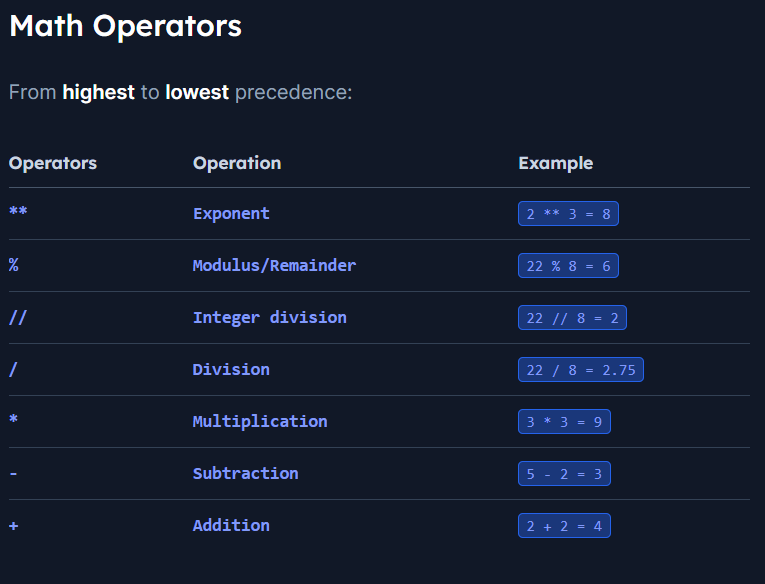

<h1> <b> <u> Data Types in Python </u> </b> </h1>

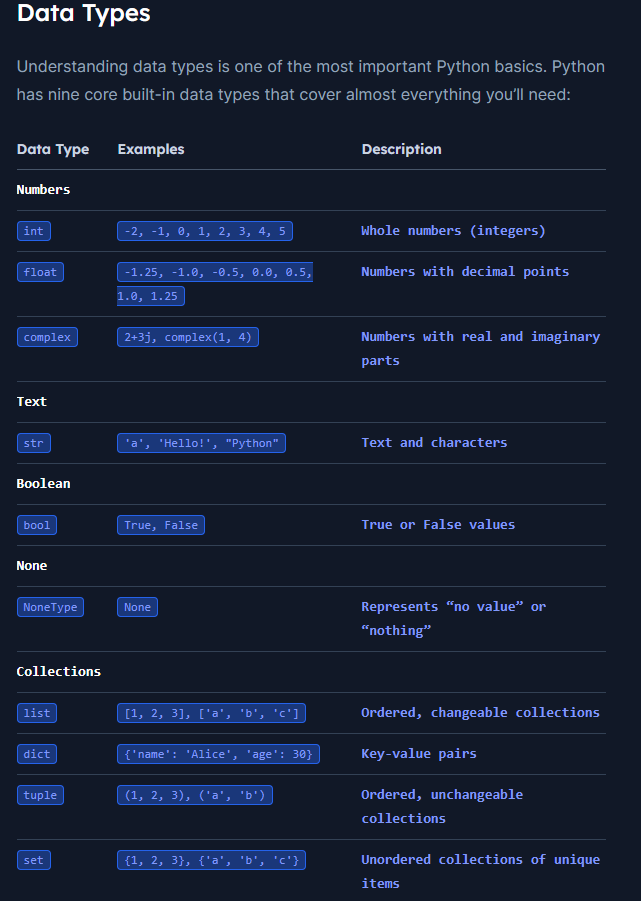

<h1><b><u>Standard Library</u></b></h1>

* Argparse
* Collections
* Copy
* CSV
* Datetime
* Itertools
* JSON
* Functools
* Hashlib
* Logging
* Math
* OS
* Pathlib
* Random
* re
* Shelve
* SQLite3
* Statistics
* Subprocess
* Sys
* Tempfile
* Threading
* Tomllib
* Typing
* urllib.request
* Zoneinfo
* Zipfile


<h1> Argparse </h1>

In [ ]:
import argparse
#Use argparse when you want a Python file to behave like a small terminal program:

# *ArgumentParser stores the arguments your program accepts.
parser = argparse.ArgumentParser(
    prog='greet',
    description='Greet a user from the command line',
)
parser.print_help()


#Positional arguments
#Positional arguments are required by default.

parser = argparse.ArgumentParser()
parser.add_argument('name')

args = parser.parse_args(['Ada'])
print(args.name)



# Optional arguments and flags
# Optional arguments usually start with - or --.

parser = argparse.ArgumentParser()
parser.add_argument('--count', type=int, default=1)
parser.add_argument('-v', '--verbose', action='store_true')

args = parser.parse_args(['--count', '3', '--verbose'])
print(args.count)
print(args.verbose)

# Subcommands
# Subcommands are useful for tools like git commit or docker run.

parser = argparse.ArgumentParser()
subparsers = parser.add_subparsers(dest='command', required=True)

build_parser = subparsers.add_parser('build')
build_parser.add_argument('--release', action='store_true')

args = parser.parse_args(['build', '--release'])
print(args.command)
print(args.release)



usage: greet [-h]

Greet a user from the command line

options:
  -h, --help  show this help message and exit
Ada
3
True


In [9]:
# Python Collections Module
# Share
# The collections module provides specialized container datatypes such as Counter, defaultdict, and deque.

from collections import Counter, defaultdict, deque
# Use these classes when regular list and dict objects work, but make the code awkward or slower.

# Counter
# Counter counts hashable objects.

from collections import Counter

letters = Counter('banana')
print(letters)
print(letters['a'])
# You can also ask for the most common values:

from collections import Counter

words = ['python', 'java', 'python', 'go', 'python', 'go']
counts = Counter(words)
print(counts.most_common(2))
# defaultdict
# defaultdict creates missing keys automatically.

from collections import defaultdict

scores = defaultdict(list)
scores['python'].append(10)
scores['python'].append(9)
print(scores['python'])
print(scores['javascript'])
[10, 9]
[]
# This is useful when grouping data:

from collections import defaultdict

users = [('Ada', 'admin'), ('Grace', 'editor'), ('Linus', 'admin')]
by_role = defaultdict(list)

for name, role in users:
    by_role[role].append(name)

print(dict(by_role))
# deque
# deque is efficient for appending and popping from both ends.

from collections import deque

tasks = deque(['build', 'test'])
tasks.appendleft('lint')
tasks.append('deploy')
print(tasks.popleft())
print(tasks.pop())
print(tasks)


# deque can also keep only the newest values with maxlen:

from collections import deque

recent = deque(maxlen=3)
for page in ['home', 'docs', 'blog', 'contact']:
    recent.append(page)

print(recent)


Counter({'a': 3, 'n': 2, 'b': 1})
3
[('python', 3), ('go', 2)]
[10, 9]
[]
{'admin': ['Ada', 'Linus'], 'editor': ['Grace']}
lint
deploy
deque(['build', 'test'])
deque(['docs', 'blog', 'contact'], maxlen=3)


In [10]:
# Python SQLite3 Module
# Share
# The sqlite3 module lets you use SQLite databases directly from Python without a separate database server.

# import sqlite3
# SQLite is a good choice for small apps, local tools, tests, and learning SQL. The database can live in a single file, or only in memory with ':memory:'.

# Connecting to a database
# SQLite can create the database file automatically if it does not exist.

import sqlite3

connection = sqlite3.connect(':memory:')
print(type(connection).__name__)
# Creating a table and inserting rows
import sqlite3

connection = sqlite3.connect(':memory:')
cursor = connection.cursor()

cursor.execute('CREATE TABLE users (name TEXT, age INTEGER)')
cursor.execute('INSERT INTO users VALUES (?, ?)', ('Ada', 36))
cursor.execute('INSERT INTO users VALUES (?, ?)', ('Grace', 40))
connection.commit()
# Use placeholders instead of formatting SQL strings manually.

# WARNING

# Do not build SQL queries by concatenating user input. Use placeholders like ? to avoid SQL injection bugs.

# Querying rows
rows = cursor.execute('SELECT name, age FROM users ORDER BY age').fetchall()
print(rows)
# Using Row objects
# Row lets you access columns by name.

connection = sqlite3.connect(':memory:')
connection.row_factory = sqlite3.Row
cursor = connection.cursor()
cursor.execute('CREATE TABLE projects (name TEXT)')
cursor.execute('INSERT INTO projects VALUES (?)', ('python-cheatsheet',))
row = cursor.execute('SELECT name FROM projects').fetchone()
print(row['name'])
# Using a context manager
# The connection can be used with with so changes are committed automatically if there is no error.

import sqlite3

with sqlite3.connect(':memory:') as connection:
    connection.execute('CREATE TABLE notes (body TEXT)')
    connection.execute('INSERT INTO notes VALUES (?)', ('Learn sqlite3',))
    rows = connection.execute('SELECT body FROM notes').fetchall()

print(rows)


Connection
[('Ada', 36), ('Grace', 40)]
python-cheatsheet
[('Learn sqlite3',)]


<h1> Encapsulation </h1>
Encapsulation is one of the fundamental concepts of object-oriented programming, which helps to protect the data and methods of an object from unauthorized access and modification. It is a way to achieve data abstraction, which means that the implementation details of an object are hidden from the outside world, and only the essential information is exposed.

In [11]:
# Define a class named MyClass
class MyClass:

    # Constructor method that initializes the class object
    def __init__(self):

        # Define a protected variable with an initial value of 10
        # The variable name starts with a single underscore, which indicates protected access
        self._protected_var = 10

        # Define a private variable with an initial value of 20
        # The variable name starts with two underscores, which indicates private access
        self.__private_var = 20

# Create an object of MyClass class
obj = MyClass()

# Access the protected variable using the object name and print its value
# The protected variable can be accessed outside the class but
# it is intended to be used within the class or its subclasses
print(obj._protected_var)   # output: 10

# Try to access the private variable using the object name and print its value
# The private variable cannot be accessed outside the class, even by its subclasses
# This will raise an AttributeError because the variable is not accessible outside the class
print(obj.__private_var)    # AttributeError: 'MyClass' object has no attribute '__private_var'



10


AttributeError: 'MyClass' object has no attribute '__private_var'

<h1>Inheritance</h1>
Inheritance promotes code reuse and allows you to create a hierarchy of classes that share common attributes and methods. It helps in creating clean and organized code by keeping related functionality in one place and promoting the concept of modularity. The base class from which a new class is derived is also known as a parent class, and the new class is known as the child class or subclass.

In [12]:
# Define a class named Animal
class Animal:

    # Constructor method that initializes the class object with a name attribute
    def __init__(self, name):
        self.name = name

    # Method that is defined in the Animal class but does not have a body
    # This method will be overridden in the subclasses of Animal
    def speak(self):
        print("")

# Define a subclass named Dog that inherits from the Animal class
class Dog(Animal):

    # Override the speak method of the Animal class
    def speak(self):
        print("Woof!")

# Define a subclass named Cat that inherits from the Animal class
class Cat(Animal):

    # Override the speak method of the Animal class
    def speak(self):
        print("Meow!")

# Create a Dog object with a name attribute "Rover"
dog = Dog("Rover")

# Create a Cat object with a name attribute "Whiskers"
cat = Cat("Whiskers")

# Call the speak method of the Dog class and print the output
# The speak method of the Dog class overrides the speak method of the Animal class
# Therefore, when we call the speak method of the Dog object, it will print "Woof!"
dog.speak()   # output: Woof!

# Call the speak method of the Cat class and print the output
# The speak method of the Cat class overrides the speak method of the Animal class
# Therefore, when we call the speak method of the Cat object, it will print "Meow!"
cat.speak()   # output: Meow!



Woof!
Meow!


<h1>Polymorphism</h1>
Polymorphism is an important concept in object-oriented programming that allows you to write code that can work with objects of different classes in a uniform way. In Python, polymorphism is achieved by using method overriding or method overloading.

In [13]:
#The Shape class is defined with an abstract area method, which is intended to be overridden by subclasses.
class Shape:
    def area(self):
        pass

class Rectangle(Shape):
    # The Rectangle class is defined with an __init__ method that initializes
    # width and height instance variables.
    # It also defines an area method that calculates and returns
    # the area of a rectangle using the width and height instance variables.
    def __init__(self, width, height):
        self.width = width  # Initialize width instance variable
        self.height = height  # Initialize height instance variable

    def area(self):
        return self.width * self.height  # Return area of rectangle


 # The Circle class is defined with an __init__ method
 # that initializes a radius instance variable.
 # It also defines an area method that calculates and
 # returns the area of a circle using the radius instance variable.
class Circle(Shape):
    def __init__(self, radius):
        self.radius = radius  # Initialize radius instance variable

    def area(self):
        return 3.14 * self.radius ** 2  # Return area of circle using pi * r^2

# The shapes list is created with one Rectangle object and one Circle object. The for
# loop iterates over each object in the list and calls the area method of each object
# The output will be the area of the rectangle (20) and the area of the circle (153.86).
shapes = [Rectangle(4, 5), Circle(7)]  # Create a list of Shape objects
for shape in shapes:
    print(shape.area())  # Output the area of each Shape object



20
153.86


<h1>Abstraction</h1>
Abstraction is an important concept in object-oriented programming (OOP) because it allows you to focus on the essential features of an object or system while ignoring the details that aren’t relevant to the current context. By reducing complexity and hiding unnecessary details, abstraction can make code more modular, easier to read, and easier to maintain.

In [14]:
# Import the abc module to define abstract classes and methods
from abc import ABC, abstractmethod

# Define an abstract class called Shape that has an abstract method called area
class Shape(ABC):
    @abstractmethod
    def area(self):
        pass

# Define a Rectangle class that inherits from Shape
class Rectangle(Shape):
    def __init__(self, width, height):
        self.width = width
        self.height = height

    # Implement the area method for Rectangles
    def area(self):
        return self.width * self.height

# Define a Circle class that also inherits from Shape
class Circle(Shape):
    def __init__(self, radius):
        self.radius = radius

    # Implement the area method for Circles
    def area(self):
        return 3.14 * self.radius ** 2

# Create a list of shapes that includes both Rectangles and Circles
shapes = [Rectangle(4, 5), Circle(7)]

# Loop through each shape in the list and print its area
for shape in shapes:
    print(shape.area())



20
153.86
